# Signal Respirometry — Project Setup

This notebook bootstraps a standard structure for data analysis:

- `data/` — raw, processed, and external data
- `figures/` — generated plots and exports
- `video/` — raw videos and derived clips
- `notebooks/` — analysis notebooks (this file)

It also performs a quick environment check, ensures directories exist, and creates a demo plot in `figures/`.

In [10]:
# Set Project paths
from pathlib import Path
ROOT = Path('..').resolve()  # This notebook lives in notebooks/
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
VIDEO_DIR = ROOT / 'video'
NOTEBOOKS_DIR = ROOT / 'notebooks'

# Optional sub-structure under data/
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
EXTERNAL_DIR = DATA_DIR / 'external'

for p in [DATA_DIR, FIGURES_DIR, VIDEO_DIR, NOTEBOOKS_DIR, RAW_DIR, PROCESSED_DIR, EXTERNAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT      =', ROOT)
print('DATA_DIR  =', DATA_DIR)
print('FIGURES   =', FIGURES_DIR)
print('VIDEO     =', VIDEO_DIR)

ROOT      = /Users/oakley/Documents/GitHub/signal_respirometry
DATA_DIR  = /Users/oakley/Documents/GitHub/signal_respirometry/data
FIGURES   = /Users/oakley/Documents/GitHub/signal_respirometry/figures
VIDEO     = /Users/oakley/Documents/GitHub/signal_respirometry/video


## Quantification: detect pulses and blue streaks as contours

We start a simple contour-based detector that thresholds the blue channel, filters small areas, and writes centroids per frame to CSV. 

## Per-video interactive workflow (recommended)

- For each video:
  1) Set `video_name` below and (optionally) load saved params for that video.
  2) Run the extraction cell to regenerate the CSV.
  3) Use the preview/ROI cells to tune thresholds and draw ROIs.
  4) Use the final ROI-only viewer to sanity-check.
  5) Save the tuned parameters for this video (so you can recall them later).

.
Alternative: You can duplicate this notebook (one per video) if you prefer keeping everything isolated; all outputs are already keyed by video stem.

In [11]:
video_name = "GX010072.MP4"

# Toggle ROI re-selection when running end-to-end
rerun_roi = True  # False = reuse existing ROI JSON if present; True = force interactive ROI selection
print('rerun_roi =', rerun_roi)

rerun_roi = True


In [12]:
# Set current video and (optionally) load saved params for it
from pathlib import Path
import json

# Ensure paths
ROOT = Path('..').resolve()
VIDEO_DIR = ROOT / 'video'
DATA_DIR = ROOT / 'data'
CONFIG_DIR = DATA_DIR / 'config'
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Pick a default video if none set yet
videos = sorted([p.name for p in VIDEO_DIR.iterdir() if p.is_file() and p.suffix.lower() in {'.mp4','.mov','.mkv','.avi','.m4v'}])
try:
    video_name
except NameError:
    video_name = videos[0] if videos else 'GX010063.MP4'

print('Current video_name =', video_name)

# Try to load saved params for this video (if present)
params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
if params_path.exists():
    with open(params_path, 'r') as f:
        saved = json.load(f)
    # Apply known params if defined in saved JSON
    analyze_scale = float(saved.get('analyze_scale', globals().get('analyze_scale', 0.5)))
    blue_thresh   = saved.get('blue_thresh', globals().get('blue_thresh', 60))
    blur_ksize    = int(saved.get('blur_ksize', globals().get('blur_ksize', 0)))
    min_area      = float(saved.get('min_area', globals().get('min_area', 1.5)))
    use_bminusg   = bool(saved.get('use_bminusg', globals().get('use_bminusg', True)))
    seconds_per_frame = float(saved.get('seconds_per_frame', globals().get('seconds_per_frame', 30.0)))
    print('Loaded saved parameters from', params_path)
else:
    print('No saved parameters found for this video; using current defaults.')

Current video_name = GX010072.MP4
Loaded saved parameters from /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_analysis.json


In [13]:
# Save current parameters for this video (edit overrides below to change any values)
from pathlib import Path
import json

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
CONFIG_DIR = DATA_DIR / 'config'
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Base parameters come from currently defined globals (e.g., loaded from file) or sensible defaults
gs = globals()
base_params = {
    'analyze_scale': float(gs.get('analyze_scale', 0.5)),
    'blue_thresh': gs.get('blue_thresh', 60),  # may be None to use Otsu
    'blur_ksize': int(gs.get('blur_ksize', 0)),
    'min_area': float(gs.get('min_area', 1.5)),
    'use_bminusg': bool(gs.get('use_bminusg', True)),
    'seconds_per_frame': float(gs.get('seconds_per_frame', 30.0)),  # default global = 30.0
}

# Edit this dictionary to override ANY subset of params; leave keys absent to keep current values
# Examples shown; uncomment/update as needed:
overrides = {
    # 'seconds_per_frame': 30.0,
    # 'blue_thresh': 75,           # or None for Otsu
    # 'use_bminusg': False,
    # 'analyze_scale': 0.5,
    # 'blur_ksize': 3,
    # 'min_area': 2.0,
}

allowed_keys = set(base_params.keys())
unknown = set(overrides.keys()) - allowed_keys
if unknown:
    print('Warning: ignoring unknown keys in overrides:', sorted(unknown))
    for k in sorted(unknown):
        overrides.pop(k, None)

def _coerce(key, value):
    if key == 'blue_thresh':
        return int(value) if value is not None else None
    if key in ('blur_ksize',):
        return int(value)
    if key in ('analyze_scale', 'min_area', 'seconds_per_frame'):
        return float(value)
    if key == 'use_bminusg':
        return bool(value)
    return value

# Merge overrides with proper type coercion
params = base_params.copy()
for k, v in overrides.items():
    params[k] = _coerce(k, v)

# Persist to config/<stem>_analysis.json
params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
with open(params_path, 'w') as f:
    json.dump(params, f, indent=2)
print('Saved parameters to', params_path)
print('Parameters written:', json.dumps(params, indent=2))

# Update globals so subsequent cells use the newly saved values immediately
for k, v in params.items():
    globals()[k] = v

Saved parameters to /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_analysis.json


In [14]:
# Extract all contours across the entire video and find the best frame for ROI selection
from pathlib import Path
import sys, subprocess, io
import pandas as pd

# Run analyzer over the entire video (no --max-frames, no ROI)
cmd = [
    sys.executable,
    str(an_script),
    '--video', str(video_path),
    '--output', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--seconds-per-frame', str(seconds_per_frame),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
# Include mask if it exists
if mask_path.exists():
    cmd += ['--mask-in', str(mask_path)]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd, capture_output=True, text=True)
print(ret.stdout)
if ret.stderr:
    print('stderr:\n', ret.stderr)
print('Wrote detections to:', csv_path)

# Load CSV (skip metadata preamble) and compute best frame (max contours)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
per_frame = df.groupby('frame').size().rename('count').reset_index()
if len(per_frame) == 0:
    raise RuntimeError('No detections found; check thresholds/scale settings.')

best_row = per_frame.loc[per_frame['count'].idxmax()]
best_frame_index = int(best_row['frame'])
best_count = int(best_row['count'])
print(f'Best frame for ROI selection: frame {best_frame_index} with {best_count} contours')
print('You can re-run ROI selection using this frame index in the next cell.')

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/analyze_streaks.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072.MP4 --output /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --seconds-per-frame 30.0 --use-bminusg --blue-thresh 60
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv
Best frame for ROI selection: frame 152 with 11 contours
You can re-run ROI selection using this frame index in the next cell.
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv
Best frame

In [15]:
# Preview the top-N frames with most contours and overlay detections (interactive)
from pathlib import Path
import sys, subprocess

# Configure
top_n = 10
line_thickness = 5  # increase for small contours
video_name = video_name  # reuse from above
csv_path = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
viewer_script = ROOT / 'scripts' / 'preview_top_contours.py'

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--top-n', str(top_n),
    '--line-thickness', str(line_thickness),
 ]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if (PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png").exists():
    cmd += ['--mask-in', str(PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png")]
print('Command:', ' '.join(cmd))
print('Controls: SPACE/RIGHT next, LEFT prev, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_top_contours.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --top-n 10 --line-thickness 5 --use-bminusg --blue-thresh 60
Controls: SPACE/RIGHT next, LEFT prev, Q/ESC quit
Exit code: 0
Exit code: 0


In [20]:
# Define ROIs (interactive)
#
# Use the ROI tool to draw rectangular regions on a frame of the video.
# This will create a JSON under data/config/<video>_rois.json and an overlay PNG in figures/.
# Tip: Press ENTER when done selecting to confirm the ROIs.

# Prefer previously computed best frame from detections
try:
    video_name
except NameError:
    raise RuntimeError("video_name is not set. Run the earlier cell that defines video_name (e.g., 'GX010072.MP4').")
try:
    frame_index = int(best_frame_index)  # from previous cell
except NameError:
    frame_index = 0
scale_for_selection = 0.5  # display scale (ROI coordinates are saved in original pixels)

import sys, subprocess, json
from pathlib import Path

ROI_ROOT = Path('..').resolve()
VIDEO_DIR = ROI_ROOT / 'video'
DATA_DIR = ROI_ROOT / 'data'
FIGURES_DIR = ROI_ROOT / 'figures'

roi_script = ROI_ROOT / "scripts" / "define_rois.py"
video_path = VIDEO_DIR / video_name
roi_json_path = DATA_DIR / "config" / f"{video_path.stem}_rois.json"
overlay_png = FIGURES_DIR / f"{video_path.stem}_rois_overlay.png"

# Decide whether to re-run interactive ROI selection
try:
    rerun = bool(rerun_roi)
except NameError:
    rerun = False

print("Using video for ROI:", video_path)
print("ROI JSON target:", roi_json_path)
print("Overlay target:", overlay_png)

if (not rerun) and roi_json_path.exists():
    print("Skipping ROI definition: existing ROI JSON found at", roi_json_path)
    print("Set rerun_roi = True to re-draw ROIs interactively.")
    if overlay_png.exists():
        print("Overlay preview:", overlay_png)
else:
    cmd = [
        sys.executable,
        str(roi_script),
        "--video", str(video_path),
        "--frame-index", str(frame_index),
        "--scale", str(scale_for_selection),
        "--output", str(roi_json_path),
        "--preview", str(overlay_png),
    ]
    print("Command:", " ".join(cmd))
    ret = subprocess.run(cmd, capture_output=True, text=True)
    print(ret.stdout)
    if ret.stderr:
        print("stderr:\n", ret.stderr)
    print("ROI JSON:", roi_json_path)
    print("Overlay preview (if created):", overlay_png)

Using video for ROI: /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072.MP4
ROI JSON target: /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_rois.json
Overlay target: /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010072_rois_overlay.png
Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/define_rois.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072.MP4 --frame-index 152 --scale 0.5 --output /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_rois.json --preview /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010072_rois_overlay.png
Finish the selection process by pressing ESC button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI an

In [21]:
# Adjustable clock start for plotting
# Set as 'HH:MM' or 'HH:MM:SS' and rerun this cell before the plotting cell.
start_clock = '19:00'
print('start_clock =', start_clock)

start_clock = 19:00


Totals per region (in-ROI only):
 region
right     2361
middle     115
left        25
dtype: int64
Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010072_detections_in_roi_1s.png


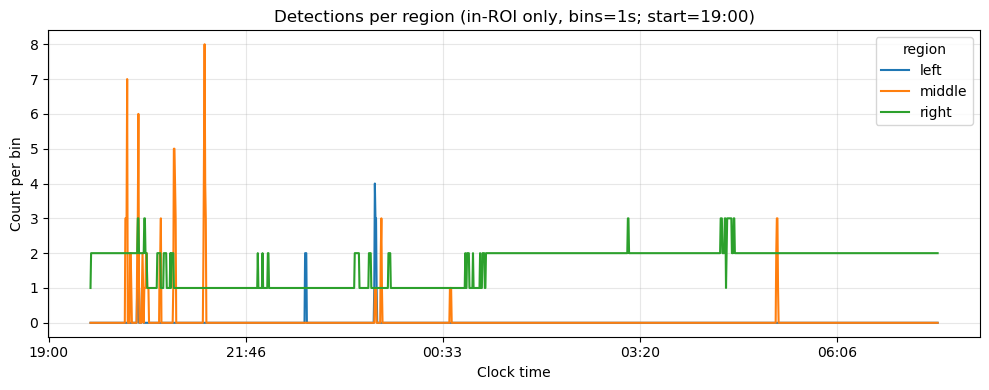

Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010072_detections_in_roi_60s.png


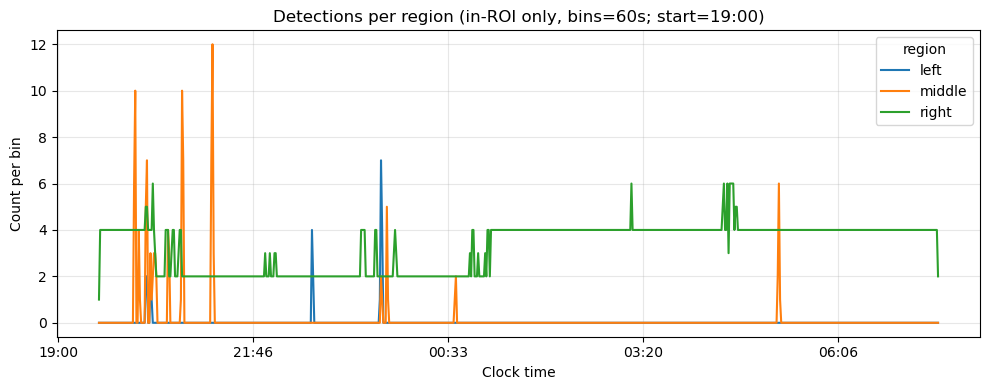

In [22]:
# Apply ROI to detections in-notebook and plot rates by region (exclude 'outside')
import io, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from pathlib import Path

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
VIDEO_DIR = ROOT / 'video'
CONFIG_DIR = DATA_DIR / 'config'

# Inputs
csv_path = DATA_DIR / 'processed' / f'{Path(video_name).stem}_streaks.csv'
roi_json_path = DATA_DIR / 'config' / f'{Path(video_name).stem}_rois.json'

# Sanity checks for required inputs
if not csv_path.exists():
    raise FileNotFoundError(f"Detections CSV not found: {csv_path}. Run the extraction cell first.")
if not roi_json_path.exists():
    available = sorted(p.name for p in CONFIG_DIR.glob('*_rois.json'))
    msg = [
        f"ROI JSON not found for {Path(video_name).stem} at {roi_json_path}.",
        "- Did you run the ROI selection cell and press ENTER to confirm?",
        f"- Expected filename: {Path(video_name).stem}_rois.json",
        f"- Available ROI files in {CONFIG_DIR}: {available if available else 'None found'}",
        "- If you want to reuse a different video's ROI, copy it to this stem or set video_name accordingly.",
    ]
    raise FileNotFoundError("\n".join(msg))

# Load detections (skip preamble)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))

# Determine scale used by analyzer (from variable if available, else from preamble)
try:
    scale_used = float(analyze_scale)
except NameError:
    # parse from preamble line 2 (metadata values)
    meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
    scale_used = float(meta_vals[3]) if len(meta_vals) >= 4 else 1.0

# Load ROI JSON (rects in original pixels)
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
orig_w = int(roi_cfg['original_size']['width'])
orig_h = int(roi_cfg['original_size']['height'])
rects = roi_cfg['rects']

# Scale ROIs to detection coordinate space (scaled by scale_used)
scaled_rects = []
for r in rects:
    scaled_rects.append({
        'label': r['label'],
        'x': int(round(r['x'] * scale_used)),
        'y': int(round(r['y'] * scale_used)),
        'w': int(round(r['w'] * scale_used)),
        'h': int(round(r['h'] * scale_used)),
    })

# Assign region per detection
labels = []
for _, row in df.iterrows():
    cx, cy = float(row['cx']), float(row['cy'])
    lab = 'outside'
    for r in scaled_rects:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    labels.append(lab)

df['region'] = labels

# Exclude 'outside' from totals and plots
df_in = df[df['region'] != 'outside'].copy()

# Adjustable clock start: set as HH:MM or HH:MM:SS (e.g., '19:00', '19:15', '19:00:30')
try:
    start_clock
except NameError:
    start_clock = '19:00'

def _parse_start_clock(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("start_clock must be 'HH:MM' or 'HH:MM:SS'")
    h = int(parts[0]) % 24
    m = int(parts[1])
    sec = int(parts[2]) if len(parts) > 2 else 0
    return h * 3600 + m * 60 + sec

_start_offset = _parse_start_clock(start_clock)

if df_in.empty:
    print("No in-ROI detections to plot.")
else:
    # Totals per region (in-ROI only)
    region_totals = df_in.groupby('region').size().sort_values(ascending=False)
    print('Totals per region (in-ROI only):\n', region_totals)

    # Helper: format x (seconds since start) as HH:MM based on start_clock
    def hhmm_formatter(x, pos):
        total_seconds = float(x) + _start_offset
        hours = int((total_seconds // 3600) % 24)
        minutes = int((total_seconds % 3600) // 60)
        return f"{hours:02d}:{minutes:02d}"

    # Plot bin counts at 1s and 60s (in-ROI only) with HH:MM x-axis
    for bin_seconds in (1.0, 60.0):
        dfb = df_in.copy()
        dfb['time_bin'] = (dfb['time_s'] // bin_seconds) * bin_seconds
        counts = dfb.groupby(['region', 'time_bin']).size().reset_index(name='count')
        pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
        fig, ax = plt.subplots(figsize=(10, 4))
        pivot.plot(ax=ax)
        ax.set_title(f'Detections per region (in-ROI only, bins={bin_seconds:.0f}s; start={start_clock})')
        ax.set_xlabel('Clock time')
        ax.set_ylabel('Count per bin')
        # Format x-axis ticks as HH:MM based on seconds since start
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(hhmm_formatter))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # Save figure with video stem in figures directory
        out_path = FIGURES_DIR / f"{Path(video_name).stem}_detections_in_roi_{int(bin_seconds)}s.png"
        plt.savefig(out_path, dpi=200)
        print('Saved figure to', out_path)
        plt.show()

In [23]:
# Final visual check: overlay ONLY in-ROI detections on the video (yellow)
# with labels of which LOI they are in
from pathlib import Path
import sys, subprocess

# Paths and inputs
ROOT = Path('..').resolve()
VIDEO_DIR = ROOT / 'video'
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
CONFIG_DIR = DATA_DIR / 'config'

try:
    video_name
except NameError:
    video_name = "GX010063.MP4"

csv_path = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"
viewer_script = ROOT / 'scripts' / 'preview_contours_with_roi.py'

# Viewer options
line_thickness = 5
show_roi_edges = True   # draw ROI rectangles for context
start_frame = 0         # change to focus on a specific segment

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--roi-config', str(roi_json_path),
    '--line-thickness', str(line_thickness),
]

# Use the detection scale if available from earlier cell
try:
    cmd += ['--scale', str(float(analyze_scale))]
except NameError:
    pass

if show_roi_edges:
    cmd += ['--show-roi']

print('Command:', ' '.join(cmd))
print('Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_contours_with_roi.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010072.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010072_streaks.csv --roi-config /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010072_rois.json --line-thickness 5 --scale 0.5 --show-roi
Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit
Exit code: 0
Exit code: 0
